In [1]:
import scanpy as sc
import anndata as ad
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('supp/exp_all_for_rebuttal.csv', index_col = 0)

In [3]:
# pseudo bulk = for each enhancer, take the average expression across all cells
# this dataframe contains the raw cell x enh output from the step 3
df

,ORL10,ORL11,ORL12,ORL13,ORL14,ORL15,ORL16,ORL17,ORL18,ORL19,...,ORL56,ORL58,ORL59,ORL6,ORL60,ORL67,ORL7,ORL8,ORL9,Otx-a WT
AAACCAAAGGAATTAG-1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,...,0.000000,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
AAACCATTCGATCATG-1,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,0.000000,...,0.000000,0.0,3.148611,0.0,0.0,0.0,0.0,0.0,NaN,0.0
AAACCCGCAAGTTAGC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCCGCAATCGAGT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCCGCAATGCGTG-1,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,4.198149,0.0,0.000000,NaN,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTGCGGTTC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTGTACGTTAATCGC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTGTTGAGGTACGGA-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.530676,...,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
TGTGTTGAGGTCGAAG-1,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [4]:
bulk = df.mean().to_frame()

In [5]:
lookup = pd.read_csv("../6-grammar_final/refs/final_enhancer_ebc_cbc_lookup.csv")

In [6]:
selected_enhancers = lookup[['bin-anno', 'enhancer_id']].drop_duplicates()
selected_enhancers['bin-anno'] = selected_enhancers['bin-anno'].map({'Moderate':'Dependent'}).fillna(selected_enhancers['bin-anno'])
test_bin2eh = selected_enhancers.groupby('bin-anno').agg(list).to_dict()['enhancer_id']

In [7]:
test_bin2eh = {k: test_bin2eh[k] for k in ['Inert', 'Dependent', 'Robust']}

In [8]:
bulk = selected_enhancers.merge(bulk, left_on = 'enhancer_id', right_index = True, how = 'right')

In [44]:
bulk = bulk[~bulk['enhancer_id'].isin(['ORL22', 'ORL33', 'ORL23', 'Otx-a WT'])]

In [11]:
# those that should be changed
bulk.loc[bulk['enhancer_id'].isin(['ORL13', 'ORL15', 'ORL11', 'ORL10', 'ORL9', 'ORL8', 'ORL14', 'ORL22']), 'bin-anno'] = 'Dependent - inert'

In [12]:
bulk['bin-anno'] = bulk['bin-anno'].map({'Dependent':'Dependent - active'}).fillna(bulk['bin-anno'])

In [32]:
bulk_scale['exp_level'] = bulk_scale['exp_level']* (1.2/0.668193)

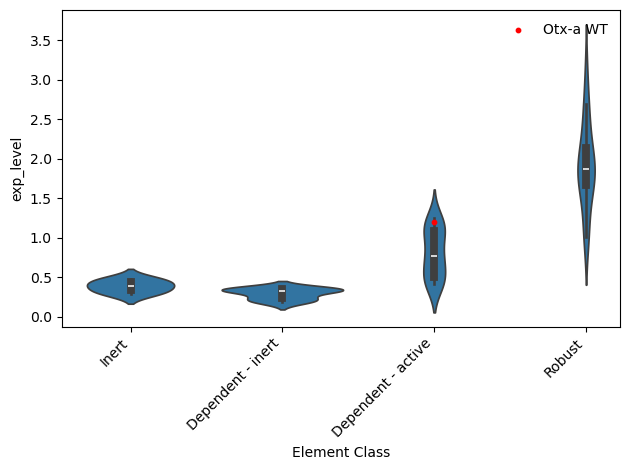

In [34]:
order = ['Inert', 'Dependent - inert', 'Dependent - active', 'Robust']

sns.violinplot(data=bulk_scale, x='bin-anno', y='exp_level', order=order)

# Get the single row
ol1 = bulk_scale[bulk_scale['enhancer_id'] == 'Otx-a WT']

# Map its bin-anno category to an x position
x_pos = order.index(ol1['bin-anno'].values[0])

plt.scatter(x=x_pos, y=ol1['exp_level'].values[0],
            color='red', zorder=5, s=10, label='Otx-a WT')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Element Class')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()